# NN_02c — Ablation Study: z_eq Sufficiency & Feature Importance

## Objetivo

Este notebook investiga sistematicamente se o sinal normalizado `z_eq` é suficiente para autenticação em camada física, ou se parâmetros adicionais (ganho de canal $h$, SNR estimado, e correlator clássico $\tau_{eq}$) melhoram significativamente o desempenho de detecção.

## Variantes Investigadas

A investigação compara nove variantes de entrada (A, A2, B, B2, D, E, E2, F, F2) treinadas sob a mesma arquitetura DNN totalmente conectada. A **Variante A** estabelece a linha de base: uma rede densa que processa apenas o resíduo normalizado $z_{eq}$, contendo 1024 amostras do sinal equalizado. Esta variante testa se a representação vetorial bruta de $z_{eq}$ é suficientemente discriminatória para o classificador aprender sozinho sem ajuda externa.

A **Variante B** estende a Variante A incorporando o ganho de canal estimado $h$ como entrada auxiliar escalar. A motivação é validar se informação causal sobre o estado do canal instantâneo melhora a capacidade da rede de aprender limiares adaptativos conforme previsto pelo princípio CFAR.

A **Variante F** utiliza o resíduo em escala pré-equalização, $x = y - \hat h\,(\rho_s s + \rho_t\, tag_{ref}) = \hat h\,\rho_t\,(z_{eq} - tag_{ref})$. Diferente da Variante E, aqui o ruído gaussiano NÃO é distorcido pela divisão por $\hat h$ (que amplifica a variância do ruído em desvanecimentos profundos): o fator $\hat h\,\rho_t$ cancela exatamente a escala $1/(\rho_t \hat h)$ presente em $z_{eq}$, deixando o ruído aditivo puro $w$. Esta variante substitui a Variante C (removida da investigação) e testa se a rede aprende melhor quando a variância do ruído não é artificialmente distorcida pela equalização.

A **Variante D** combina $z_{eq}$ com o correlator clássico $\tau_{eq}$ fornecido explicitamente. Este teste investiga se a incorporação da estatística suficiente de Neyman-Pearson, já computada, melhora significativamente a rede densa em comparação com deixá-la aprender este correlator implicitamente a partir do sinal bruto.

A **Variante E** avalia o sinal residual explícito $x = z_{eq} - tag_{ref}$, onde $tag_{ref}$ é a TAG legítima de referência por amostra. Esta variante mede o desempenho quando a rede recebe diretamente o erro em relação à TAG esperada.

Conforme a teoria do Data-Driven Detection Framework, se $z_{eq}$ é verdadeiramente a representação suficiente, as Variantes B, D, E e F devem exibir melhorias mínimas e marginais em relação à Variante A. Qualquer ganho detectado identifica qual informação adicional é genuinamente necessária para compensar limitações estruturais do sinal bruto em regimes de baixo SNR.

## Configuração Experimental

O experimento utiliza o dataset `dataset_cnn_yeq_0_30dB.h5` contendo 280 mil amostras de treinamento, 35 mil de validação e 35 mil de teste, estratificadas uniformemente em faixas de SNR de 0 a 30 dB. O treinamento executa em GPU (RTX 4050) com precisão mista float16 e carregamento lazy para otimizar memória. Cada modelo treina com a mesma DNN base 256→128→64, alterando apenas o vetor de entrada de cada variante. A métrica primária é a área sob a curva ROC (AUC) no conjunto de teste, complementada pela análise de probabilidade de detecção $P_D$ versus SNR sob framework D3F com restrição de falso alarme $\alpha = 0{,}01$ (η, alinhado com Xie et al. 2021, Figs. 2-3).

### Variantes de energia (A2, B2, E2, F2)

As variantes A2, B2, E2 e F2 mantêm exatamente as respectivas variantes originais e acrescentam uma única feature escalar de energia, calculada como soma dos quadrados das 1024 amostras da representação fornecida à rede. A2 acrescenta Σz² a A; B2 acrescenta Σz² a B; E2 acrescenta Σ(z_eq−tag_ref)² a E; F2 acrescenta Σx_F² ao vetor F, onde x_F = h·ρ_t·(z_eq−tag_ref). Essas variantes são controles aumentados e não substituem as originais.


In [1]:
# ==============================================================================
# 1. GPU CONFIG & IMPORTS
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import h5py
import json
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
import psutil
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC

print(f"TensorFlow : {tf.__version__}")

# ── GPU Configuration ──
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs found : {len(gpus)}")

USE_GPU = False
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        USE_GPU = True
        print(f"✅ Memory growth enabled on {len(gpus)} GPU(s).")
    except Exception as e:
        print(f"⚠️  Error: {e}")
        USE_GPU = False

# ── Mixed precision (GPU only) ──
if USE_GPU:
    try:
        policy = keras.mixed_precision.Policy('mixed_float16')
        keras.mixed_precision.set_global_policy(policy)
        print(f"✅ Mixed precision: {policy.name}")
    except Exception as e:
        print(f"⚠️  Mixed precision failed: {e}")

# ── Disable XLA (avoid hangs on WSL) ──
ENABLE_XLA = False
keras.backend.clear_session()

# ── Paths ──
project_root       = Path.cwd().parent
results_dir        = project_root / "results"
data_dir           = results_dir / "data"
models_dir         = results_dir / "models"
visualizations_dir = results_dir / "Figures2"

for d in [models_dir, visualizations_dir]:
    d.mkdir(parents=True, exist_ok=True)

dataset_path = data_dir / "dataset_cnn_yeq_0_30dB.h5"

if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset not found: {dataset_path}")

print(f"\n📂 Paths:")
print(f"  Data: {data_dir}")
print(f"  Models: {models_dir}")
print(f"  Visualizations: {visualizations_dir}")

I0000 00:00:1788232418.255338  655923 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788232418.887862  655923 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788232421.561851  655923 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.21.0
GPUs found : 1
✅ Memory growth enabled on 1 GPU(s).
✅ Mixed precision: mixed_float16

📂 Paths:
  Data: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data
  Models: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models
  Visualizations: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/Figures2


In [2]:
# ==============================================================================
# 2. LAZY LOAD DATASET & PREPARE MULTI-INPUT VARIANTS
# ==============================================================================

def load_h5_generator(h5_path, split, chunk_size=2000):
    """Lazy HDF5 loader — yields (z_eq, h, snr, tau_eq, label, tag_ref) per sample."""
    with h5py.File(str(h5_path), 'r') as f:
        z_data   = f[f'{split}/z_eq']
        h_data   = f[f'{split}/h']
        snr_data = f[f'{split}/snr']
        tau_data = f[f'{split}/tau_eq']
        y_data   = f[f'{split}/y']

        # Accept multiple aliases for the legitimate reference TAG tensor.
        tag_keys = [
            f'{split}/tag_ref',
            f'{split}/tag_legit',
            f'{split}/tag',
            f'{split}/t_ref',
            f'{split}/tag_reference',
        ]
        tag_key = next((k for k in tag_keys if k in f), None)
        tag_data = f[tag_key] if tag_key is not None else None

        for start_idx in range(0, len(z_data), chunk_size):
            end_idx  = min(start_idx + chunk_size, len(z_data))
            z_chunk   = z_data[start_idx:end_idx].astype(np.float32)
            h_chunk   = h_data[start_idx:end_idx].astype(np.float32)
            snr_chunk = snr_data[start_idx:end_idx].astype(np.float32)
            tau_chunk = tau_data[start_idx:end_idx].astype(np.float32)
            y_chunk   = y_data[start_idx:end_idx].astype(np.float32)
            if tag_data is not None:
                tag_chunk = tag_data[start_idx:end_idx].astype(np.float32)
            else:
                tag_chunk = np.zeros_like(z_chunk, dtype=np.float32)

            for i in range(len(z_chunk)):
                yield z_chunk[i], h_chunk[i], snr_chunk[i], tau_chunk[i], y_chunk[i], tag_chunk[i]

# Load metadata
with h5py.File(str(dataset_path), 'r') as f:
    L_FIXED = int(f.attrs['L_FIXED'])
    RHO_S   = float(f.attrs.get('RHO_S', 0.948683))
    RHO_T   = float(f.attrs.get('RHO_T', 0.316227))

    n_train = len(f['train/z_eq'])
    n_val   = len(f['val/z_eq'])
    n_test  = len(f['test/z_eq'])

    train_tag_keys = [
        'train/tag_ref',
        'train/tag_legit',
        'train/tag',
        'train/t_ref',
        'train/tag_reference',
    ]
    TAG_REF_KEY = next((k for k in train_tag_keys if k in f), None)
    HAS_TAG_REF = TAG_REF_KEY is not None

print(f"\n📊 Dataset Metadata:")
print(f"  L_FIXED={L_FIXED}, RHO_S={RHO_S:.6f}, RHO_T={RHO_T:.6f}")
print(f"  Train: {n_train}, Val: {n_val}, Test: {n_test}")
if HAS_TAG_REF:
    print(f"  TAG de referência detectada no HDF5: {TAG_REF_KEY}")
else:
    print("  ⚠️  TAG de referência não encontrada no HDF5.")
    print("     A Variante E (z_eq - tag_ref) exige um campo por amostra no dataset.")

BATCH_SIZE = 512 if USE_GPU else 256
AUTOTUNE   = tf.data.AUTOTUNE
VARIANT_INPUT_DIMS = {
    'A': L_FIXED,
    'A2': L_FIXED + 1,
    'B': L_FIXED + 1,
    'B2': L_FIXED + 2,
    'D': L_FIXED + 1,
    'E': L_FIXED,
    'E2': L_FIXED + 1,
    'F': L_FIXED,
    'F2': L_FIXED + 1,
}

def concat_scalar_features(z, *scalars):
    scalar_vec = tf.stack([tf.cast(s, tf.float32) for s in scalars], axis=0)
    return tf.concat([z, scalar_vec], axis=0)

def create_dataset(split, variant='A'):
    """Create tf.data.Dataset with a single DNN-ready feature vector per variant.
   
    Todas as variantes são convertidas para um único vetor de entrada para que
    a comparação seja puramente entre conjuntos de features, não entre
    arquiteturas ou esquemas de fusão diferentes.
   
    Variant A:  z_eq[L]
    Variant A2: concat(z_eq[L], sum(z_eq^2)[1])
    Variant B:  concat(z_eq[L], h[1])
    Variant B2: concat(z_eq[L], h[1], sum(z_eq^2)[1])
    Variant D:  concat(z_eq[L], |tau_eq|[1])
    Variant E:  z_eq[L] - tag_ref[L]
    Variant E2: concat(z_eq[L] - tag_ref[L], sum((z_eq-tag_ref)^2)[1])
    Variant F:  h*rho_t*(z_eq[L] - tag_ref[L])
    Variant F2: concat(F, sum(F^2)[1])
               (F/F2: residuo pre-equalizacao; a energia de F2 e da mesma
                representacao escalada que e entregue a rede)
    """
    gen_ds = tf.data.Dataset.from_generator(
        lambda: load_h5_generator(dataset_path, split, chunk_size=2000),
        output_signature=(
            tf.TensorSpec(shape=(L_FIXED,), dtype=tf.float32),  # z_eq
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # h
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # snr
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # tau_eq
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # y (label)
            tf.TensorSpec(shape=(L_FIXED,), dtype=tf.float32),  # tag_ref
        )
    )

    if variant == 'A':
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (z, y))
    elif variant == 'A2':
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (concat_scalar_features(z, tf.reduce_sum(tf.square(z))), y))
    elif variant == 'B':
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (concat_scalar_features(z, h), y))
    elif variant == 'B2':
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (concat_scalar_features(z, h, tf.reduce_sum(tf.square(z))), y))
    elif variant == 'D':
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (concat_scalar_features(z, tf.abs(tau)), y))
    elif variant == 'E':
        if not HAS_TAG_REF:
            raise ValueError(
                "Variante E requer TAG legítima por amostra no HDF5 "
                "(ex.: tag_ref/tag_legit/tag_reference)."
            )
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (z - tag, y))
    elif variant == 'E2':
        if not HAS_TAG_REF:
            raise ValueError(
                "Variante E2 requer TAG legítima por amostra no HDF5 "
                "(ex.: tag_ref/tag_legit/tag_reference)."
            )
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (concat_scalar_features(z - tag, tf.reduce_sum(tf.square(z - tag))), y))
    elif variant == 'F':
        if not HAS_TAG_REF:
            raise ValueError(
                "Variante F requer TAG legítima por amostra no HDF5 "
                "(ex.: tag_ref/tag_legit/tag_reference)."
            )
        # x = h*rho_t*(z_eq - tag_ref) = y_raw - h*(rho_s*msg + rho_t*tag_ref)
        # Cancela exatamente o fator 1/(rho_t*h) presente em z_eq, deixando o
        # ruido aditivo w com variancia NAO distorcida pelo desvanecimento h.
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: ((h * RHO_T) * (z - tag), y))
    elif variant == 'F2':
        if not HAS_TAG_REF:
            raise ValueError(
                "Variante F2 requer TAG legítima por amostra no HDF5 "
                "(ex.: tag_ref/tag_legit/tag_reference)."
            )
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (
            concat_scalar_features(
                (h * RHO_T) * (z - tag),
                tf.reduce_sum(tf.square((h * RHO_T) * (z - tag)))
            ), y
        ))
    else:
        raise ValueError(f'Variante desconhecida: {variant}')

    if split == 'train':
        ds = ds.shuffle(buffer_size=min(10000, n_train),
                        reshuffle_each_iteration=True, seed=42)

    ds = ds.batch(BATCH_SIZE, drop_remainder=(split == 'train'))
    ds = ds.prefetch(AUTOTUNE)
    return ds

print(f"\n✅ Dataset generators created. Ready for ablation study.")


📊 Dataset Metadata:
  L_FIXED=64, RHO_S=0.948683, RHO_T=0.547723
  Train: 280000, Val: 35000, Test: 35000
  TAG de referência detectada no HDF5: train/tag_ref

✅ Dataset generators created. Ready for ablation study.


In [3]:
def build_dnn_classifier(input_dim, variant):
    """Builds the shared DNN used by all z_eq ablation variants."""
    inputs = layers.Input(shape=(input_dim,), name=f'features_variant_{variant}')

    x = layers.Dense(256, kernel_initializer='he_uniform')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, kernel_initializer='he_uniform')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(1, activation='sigmoid', dtype='float32', name='p_auth')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name=f'DNN_variant_{variant}')

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=BinaryCrossentropy(from_logits=False),
        metrics=['accuracy', AUC(name='auc')],
        jit_compile=ENABLE_XLA
    )
    return model

def build_model_variant(variant, L_FIXED):
    """Constrói a mesma DNN base para todas as variantes A-E."""
    if variant not in VARIANT_INPUT_DIMS:
        raise ValueError(f'Variante desconhecida: {variant}')
    return build_dnn_classifier(VARIANT_INPUT_DIMS[variant], variant)

In [4]:
def recover_variant(variant, best_val_auc, n_epochs, train_time):
    model = keras.models.load_model(str(models_dir / f'dnn_variant_{variant}_best.keras'))
    val_ds  = create_dataset('val',  variant=variant)
    test_ds = create_dataset('test', variant=variant)

    def predict_batches(ds):
        scores = []
        for batch_x, _ in ds:
            p = model(batch_x, training=False)
            scores.append(p.numpy().flatten())
        return np.concatenate(scores)

    sc_val  = predict_batches(val_ds)[:len(snr_val_arr)]
    sc_test = predict_batches(test_ds)[:len(snr_test_arr)]

    pd_d3f = {}
    for snr in SNR_BINS:
        m0 = (snr_val_arr  >= snr-2.5) & (snr_val_arr  < snr+2.5) & (lbl_val_arr  == 0)
        m1 = (snr_test_arr >= snr-2.5) & (snr_test_arr < snr+2.5) & (lbl_test_arr == 1)
        if m0.sum() < 50 or m1.sum() < 10:
            pd_d3f[snr] = 0.0; continue
        mu, sig = sc_val[m0].mean(), sc_val[m0].std()
        if sig < 1e-10: pd_d3f[snr] = 0.0; continue
        thr = float(mu + Q_INV_D3F * sig)
        pd_d3f[snr] = float((sc_test[m1] >= thr).mean())

    results_ablation[variant] = {
        'label': VARIANT_INFO[variant],
        'best_val_auc': best_val_auc,
        'n_epochs': n_epochs,
        'train_time': train_time,
        'sc_val': sc_val, 'sc_test': sc_test, 'pd_d3f': pd_d3f,
        'history': None,
    }
    del model
    keras.backend.clear_session()
    print(f"✅ Variante {variant} recuperada.")

In [ ]:
# Preencha esta célula apenas quando já existirem checkpoints DNN salvos.
# Exemplo:
#recover_variant('E', best_val_auc=0.95, n_epochs=32, train_time=4100.0)
#print('Nenhuma variante DNN foi recuperada automaticamente nesta sessão.')

In [7]:
# ==============================================================================
# RECUPERAÇÃO DE TODAS AS VARIANTES PARA results_ablation
# NÃO TREINA NADA
# ==============================================================================

import json
import numpy as np
from pathlib import Path

# --------------------------------------------------------------------------
# 1. Variantes esperadas
# --------------------------------------------------------------------------

ALL_VARIANTS = [
    'A',
    'A2',
    'B',
    'B2',
    'D',
    'E',
    'E2',
    'F',
    'F2',
]

# --------------------------------------------------------------------------
# 2. Diretório onde os workers salvaram os resultados
# --------------------------------------------------------------------------

if 'models_dir' not in globals():
    raise NameError(
        "models_dir não está definido. "
        "Execute primeiro a célula inicial de configuração do notebook."
    )

worker_results_dir = models_dir / 'nn02c_isolated_workers'

print("=" * 80)
print("RECUPERAÇÃO DOS RESULTADOS DOS WORKERS")
print("=" * 80)
print(f"Diretório:")
print(f"  {worker_results_dir}")
print()

if not worker_results_dir.exists():
    raise FileNotFoundError(
        f"A pasta dos resultados dos workers não existe:\n"
        f"{worker_results_dir}"
    )

# --------------------------------------------------------------------------
# 3. Descrições das variantes
# --------------------------------------------------------------------------

VARIANT_INFO_RECOVERY = {
    'A':
        'z_eq[1024] (DNN pura)',

    'A2':
        'z_eq[1024] + Σz²',

    'B':
        'z_eq + h',

    'B2':
        'z_eq + h + Σz²',

    'D':
        'z_eq + |τ|',

    'E':
        'z_eq - tag_ref[1024]',

    'E2':
        '(z_eq - tag_ref) + Σ(z_eq - tag_ref)²',

    'F':
        'h·ρ_t·(z_eq - tag_ref)',

    'F2':
        'h·ρ_t·(z_eq - tag_ref) + Σ[h·ρ_t·(z_eq - tag_ref)]²',
}

# --------------------------------------------------------------------------
# 4. Função para carregar uma variante
# --------------------------------------------------------------------------

def load_worker_result_for_ablation(variant):

    meta_path = (
        worker_results_dir /
        f'nn02c_worker_{variant}_meta.json'
    )

    scores_path = (
        worker_results_dir /
        f'nn02c_worker_{variant}_scores.npz'
    )

    # ---- verificar arquivos ----

    if not meta_path.exists():
        return None, f"JSON não encontrado: {meta_path.name}"

    if not scores_path.exists():
        return None, f"NPZ não encontrado: {scores_path.name}"

    # ---- metadata ----

    with open(meta_path, 'r', encoding='utf-8') as f:
        meta = json.load(f)

    # ---- scores ----

    with np.load(scores_path) as data:

        if 'sc_val' not in data.files:
            return None, (
                f"{scores_path.name} não contém 'sc_val'. "
                f"Encontrado: {data.files}"
            )

        if 'sc_test' not in data.files:
            return None, (
                f"{scores_path.name} não contém 'sc_test'. "
                f"Encontrado: {data.files}"
            )

        sc_val = data['sc_val'].copy()
        sc_test = data['sc_test'].copy()

    # ---- PD ----
    #
    # O worker atual salva as chaves como strings:
    #   {"0": ..., "5": ..., ...}
    #
    # Aqui normalizamos para int para que os plots possam usar:
    #   r['pd_d3f'][0]
    #   r['pd_d3f'][5]
    # etc.

    raw_pd = meta.get('pd_d3f', {})

    pd_d3f = {}

    for key, value in raw_pd.items():

        try:
            snr_key = int(key)
        except (TypeError, ValueError):
            snr_key = key

        pd_d3f[snr_key] = float(value)

    # ---- resultado final ----

    result = {
        'label': meta.get(
            'label',
            VARIANT_INFO_RECOVERY.get(
                variant,
                f'Variante {variant}'
            )
        ),

        'best_val_auc': float(
            meta.get('best_val_auc', np.nan)
        ),

        'n_epochs': int(
            meta.get('n_epochs', 0)
        ),

        'train_time': float(
            meta.get('train_time', np.nan)
        ),

        'sc_val': sc_val,

        'sc_test': sc_test,

        'pd_d3f': pd_d3f,

        # Não foram salvos pelos workers.
        # Mantemos None para compatibilidade com o notebook.
        'history': None,
    }

    # Informações extras úteis
    result['variant'] = variant

    if 'batch_size' in meta:
        result['batch_size'] = meta['batch_size']

    if 'pid' in meta:
        result['pid'] = meta['pid']

    return result, None


# --------------------------------------------------------------------------
# 5. Construir results_ablation
# --------------------------------------------------------------------------

results_ablation = {}

print("Procurando arquivos...\n")

for variant in ALL_VARIANTS:

    result, error = load_worker_result_for_ablation(variant)

    if result is None:

        print(f"⚠️ {variant}: NÃO RECUPERADA")
        print(f"   {error}")

    else:

        results_ablation[variant] = result

        print(
            f"✅ {variant}: "
            f"AUC_val={result['best_val_auc']:.6f} | "
            f"épocas={result['n_epochs']:3d} | "
            f"sc_val={result['sc_val'].shape} | "
            f"sc_test={result['sc_test'].shape}"
        )


# --------------------------------------------------------------------------
# 6. Verificação final
# --------------------------------------------------------------------------

print("\n" + "=" * 80)
print("RESULTADOS RECUPERADOS")
print("=" * 80)

print(
    "\nresults_ablation.keys():"
)

print(
    sorted(results_ablation.keys())
)

missing = [
    v for v in ALL_VARIANTS
    if v not in results_ablation
]

if missing:

    print(
        "\n⚠️ Variantes ainda ausentes:"
    )

    print(
        missing
    )

else:

    print(
        "\n🎉 TODAS AS 9 VARIANTES FORAM RECUPERADAS."
    )


# --------------------------------------------------------------------------
# 7. Mostrar PD de cada variante
# --------------------------------------------------------------------------

if 'SNR_BINS' not in globals():
    SNR_BINS = [0, 5, 10, 15, 20, 25, 30]

print("\n" + "=" * 80)
print("PD D3F RECUPERADO")
print("=" * 80)

header = (
    f"{'Var':<5} "
    + " ".join(f"{s:>8}dB" for s in SNR_BINS)
)

print(header)
print("-" * len(header))

for variant in ALL_VARIANTS:

    if variant not in results_ablation:
        continue

    r = results_ablation[variant]

    vals = []

    for snr in SNR_BINS:

        pd = r['pd_d3f'].get(
            snr,
            np.nan
        )

        vals.append(
            f"{100 * pd:8.1f}"
        )

    print(
        f"{variant:<5} "
        + " ".join(vals)
    )


# --------------------------------------------------------------------------
# 8. Resumo AUC
# --------------------------------------------------------------------------

print("\n" + "=" * 80)
print("AUC DE VALIDAÇÃO")
print("=" * 80)

for variant in ALL_VARIANTS:

    if variant not in results_ablation:
        continue

    r = results_ablation[variant]

    print(
        f"{variant:<4} "
        f"{r['best_val_auc']:.6f}"
    )

print("\n✅ results_ablation está pronto para os plots e para o diagnóstico.")

RECUPERAÇÃO DOS RESULTADOS DOS WORKERS
Diretório:
  /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models/nn02c_isolated_workers

Procurando arquivos...

✅ A: AUC_val=0.729095 | épocas= 63 | sc_val=(35000,) | sc_test=(35000,)
✅ A2: AUC_val=0.500398 | épocas= 42 | sc_val=(35000,) | sc_test=(35000,)
✅ B: AUC_val=0.728758 | épocas= 63 | sc_val=(35000,) | sc_test=(35000,)
✅ B2: AUC_val=0.502961 | épocas= 65 | sc_val=(35000,) | sc_test=(35000,)
✅ D: AUC_val=0.987812 | épocas= 25 | sc_val=(35000,) | sc_test=(35000,)
✅ E: AUC_val=0.727393 | épocas= 63 | sc_val=(35000,) | sc_test=(35000,)
✅ E2: AUC_val=0.500199 | épocas= 27 | sc_val=(35000,) | sc_test=(35000,)
✅ F: AUC_val=0.869977 | épocas=150 | sc_val=(35000,) | sc_test=(35000,)
✅ F2: AUC_val=0.872799 | épocas=143 | sc_val=(35000,) | sc_test=(35000,)

RESULTADOS RECUPERADOS

results_ablation.keys():
['A', 'A2', 'B', 'B2', 'D', 'E', 'E2', 'F', 'F2']

🎉 TODAS AS 9 VARIANTES FORAM RECUPERADAS.

PD D3F RECUPERADO


In [12]:
# ==============================================================================
# DIAGNÓSTICO D3F — COMPARAÇÃO COM FIG. 3 DE XIE + VERIFICAÇÃO DO THRESHOLD
# ==============================================================================
#
# NÃO TREINA NADA.
#
# Objetivos:
#   1) verificar as dimensões e parâmetros reais do dataset;
#   2) reproduzir a referência da Fig. 3 de Xie:
#          rho_t^2 = 0.1
#          L = 64
#          alpha = 0.01
#          sigma2_tag = 1.0
#   3) medir AUC das DNNs;
#   4) comparar threshold Gaussiano vs quantil empírico;
#   5) medir P_FA REAL obtido por cada threshold;
#   6) medir P_D com ambos;
#   7) verificar se o problema está na aprendizagem ou no pós-processamento.
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm as scipy_norm

from sklearn.metrics import roc_auc_score

# ------------------------------------------------------------------------------
# 1. PARÂMETROS DA FIGURA 3 DE XIE
# ------------------------------------------------------------------------------

XIE_L = 64
XIE_RHO_T2 = 0.1
XIE_RHO_T = np.sqrt(XIE_RHO_T2)
XIE_SIGMA2_TAG = 1.0
XIE_ALPHA = 0.01

XIE_Q = norm.ppf(1.0 - XIE_ALPHA)

print("=" * 90)
print("DIAGNÓSTICO D3F — REFERÊNCIA FIG. 3 XIE")
print("=" * 90)

print("\nParâmetros da referência teórica:")
print(f"  L              = {XIE_L}")
print(f"  rho_t²         = {XIE_RHO_T2}")
print(f"  rho_t          = {XIE_RHO_T:.6f}")
print(f"  sigma²_tag     = {XIE_SIGMA2_TAG}")
print(f"  alpha = P_FA   = {XIE_ALPHA}")
print(f"  Q^-1(1-alpha)  = {XIE_Q:.6f}")


# ------------------------------------------------------------------------------
# 2. VERIFICAR O DATASET REAL
# ------------------------------------------------------------------------------

print("\n" + "-" * 90)
print("DATASET REAL")
print("-" * 90)

if 'dataset_path' in globals():

    print(f"Dataset: {dataset_path}")

    try:
        with h5py.File(str(dataset_path), 'r') as f:

            print("\nAtributos HDF5 relevantes:")
            for key in ['L_FIXED', 'RHO_S', 'RHO_T']:
                if key in f.attrs:
                    print(f"  {key:12s} = {f.attrs[key]}")

            # shapes
            for split in ['train', 'val', 'test']:
                if split in f:
                    print(f"\n{split}:")
                    for name in f[split].keys():
                        try:
                            print(
                                f"  {name:15s} "
                                f"shape={f[split][name].shape} "
                                f"dtype={f[split][name].dtype}"
                            )
                        except Exception:
                            pass

    except Exception as e:
        print(f"⚠️ Não foi possível inspecionar o HDF5: {e}")

else:
    print("⚠️ dataset_path não está definido.")


# ------------------------------------------------------------------------------
# 3. VERIFICAR ARRAYS JÁ CARREGADOS
# ------------------------------------------------------------------------------

print("\n" + "-" * 90)
print("ARRAYS NO KERNEL")
print("-" * 90)

for name in [
    'snr_val_arr',
    'snr_test_arr',
    'lbl_val_arr',
    'lbl_test_arr',
    'tau_val_arr',
    'tau_test_arr'
]:

    if name in globals():
        arr = globals()[name]
        print(
            f"{name:16s}: "
            f"shape={arr.shape}, "
            f"dtype={arr.dtype}, "
            f"min={np.nanmin(arr):.4g}, "
            f"max={np.nanmax(arr):.4g}"
        )
    else:
        print(f"⚠️ {name} não está definido.")


# ------------------------------------------------------------------------------
# 4. CURVA TEÓRICA DE XIE — FIG. 3
# ------------------------------------------------------------------------------

print("\n" + "-" * 90)
print("CURVA TEÓRICA XIE — FIG. 3")
print("-" * 90)

if 'xie_closed_form_rayleigh' not in globals():

    print("❌ xie_closed_form_rayleigh não está definido.")
    XIE_PD_DIAG = None

else:

    XIE_PD_DIAG = {}

    for snr in SNR_BINS:

        u0, pd_xie = xie_closed_form_rayleigh(
            L=XIE_L,
            rho_t=XIE_RHO_T,
            gBob_db=float(snr),
            alpha=XIE_ALPHA,
            sigma2_tag=XIE_SIGMA2_TAG
        )

        XIE_PD_DIAG[snr] = float(pd_xie)

        print(
            f"SNR={snr:2d} dB : "
            f"PD_Xie={pd_xie:.6f}"
        )


# ------------------------------------------------------------------------------
# 5. DIAGNÓSTICO DAS DNNs
# ------------------------------------------------------------------------------

print("\n" + "=" * 90)
print("DIAGNÓSTICO DAS VARIANTES DNN")
print("=" * 90)

# Variantes atualmente disponíveis
variants_diag = [
    v for v in
    ['A', 'A2', 'B', 'B2', 'D', 'E', 'E2', 'F', 'F2']
    if v in results_ablation
]

print(f"\nVariantes encontradas: {variants_diag}")


diagnostic_rows = []


for var in variants_diag:

    r = results_ablation[var]

    sc_val = np.asarray(r['sc_val']).reshape(-1)
    sc_test = np.asarray(r['sc_test']).reshape(-1)

    print("\n" + "-" * 90)
    print(f"VARIANTE {var} — {r['label']}")
    print("-" * 90)

    print(f"sc_val : {sc_val.shape}")
    print(f"sc_test: {sc_test.shape}")

    # ------------------------------------------------------------------
    # AUC GLOBAL
    # ------------------------------------------------------------------

    # Normalmente labels estão disponíveis no kernel.
    if 'lbl_val_arr' in globals():

        y_val = np.asarray(lbl_val_arr).reshape(-1)

        if len(y_val) == len(sc_val):

            auc_val = roc_auc_score(y_val, sc_val)

        else:
            auc_val = np.nan

    else:
        auc_val = np.nan


    if 'lbl_test_arr' in globals():

        y_test = np.asarray(lbl_test_arr).reshape(-1)

        if len(y_test) == len(sc_test):

            auc_test = roc_auc_score(y_test, sc_test)

        else:
            auc_test = np.nan

    else:
        auc_test = np.nan


    print(f"AUC validation = {auc_val:.6f}")
    print(f"AUC test       = {auc_test:.6f}")


    # ------------------------------------------------------------------
    # DIAGNÓSTICO POR SNR
    # ------------------------------------------------------------------

    for snr in SNR_BINS:

        # -----------------------------
        # índices H0 / H1
        # -----------------------------

        if (
            'snr_val_arr' not in globals()
            or 'snr_test_arr' not in globals()
            or 'lbl_val_arr' not in globals()
            or 'lbl_test_arr' not in globals()
        ):
            continue

        m0 = (
            (snr_val_arr >= snr - 2.5) &
            (snr_val_arr <  snr + 2.5) &
            (lbl_val_arr == 0)
        )

        m1 = (
            (snr_test_arr >= snr - 2.5) &
            (snr_test_arr <  snr + 2.5) &
            (lbl_test_arr == 1)
        )

        h0 = sc_val[m0]
        h1 = sc_test[m1]

        if len(h0) < 20 or len(h1) < 10:
            continue

        # -----------------------------
        # Estatísticas H0
        # -----------------------------

        mu0 = float(np.mean(h0))
        sigma0 = float(np.std(h0, ddof=1))

        # Threshold usado atualmente
        threshold_gauss = (
            mu0 + XIE_Q * sigma0
        )

        # Threshold empírico que GARANTE aproximadamente
        # P_FA = 0.01 na amostra de validação
        threshold_quantile = np.quantile(
            h0,
            1.0 - XIE_ALPHA
        )

        # -----------------------------
        # P_FA real
        # -----------------------------

        pfa_gauss = np.mean(
            h0 >= threshold_gauss
        )

        pfa_quantile = np.mean(
            h0 >= threshold_quantile
        )

        # -----------------------------
        # P_D
        # -----------------------------

        pd_gauss = np.mean(
            h1 >= threshold_gauss
        )

        pd_quantile = np.mean(
            h1 >= threshold_quantile
        )

        # -----------------------------
        # AUC local
        # -----------------------------

        y_local = np.concatenate([
            np.zeros(len(h0)),
            np.ones(len(h1))
        ])

        scores_local = np.concatenate([
            h0,
            h1
        ])

        try:
            auc_local = roc_auc_score(
                y_local,
                scores_local
            )
        except Exception:
            auc_local = np.nan

        diagnostic_rows.append({
            'variant': var,
            'snr_db': snr,

            'n_H0': len(h0),
            'n_H1': len(h1),

            'mu_H0': mu0,
            'sigma_H0': sigma0,

            'threshold_gauss': threshold_gauss,
            'threshold_quantile': threshold_quantile,

            'PFA_gauss': pfa_gauss,
            'PFA_quantile': pfa_quantile,

            'PD_gauss': pd_gauss,
            'PD_quantile': pd_quantile,

            'AUC_local': auc_local,

            'PD_Xie': (
                XIE_PD_DIAG.get(snr, np.nan)
                if XIE_PD_DIAG is not None
                else np.nan
            )
        })


# ------------------------------------------------------------------------------
# 6. TABELA
# ------------------------------------------------------------------------------

diag_df = pd.DataFrame(diagnostic_rows)

print("\n" + "=" * 90)
print("TABELA COMPLETA")
print("=" * 90)

if len(diag_df):

    display(
        diag_df.round({
            'mu_H0': 4,
            'sigma_H0': 4,
            'threshold_gauss': 4,
            'threshold_quantile': 4,
            'PFA_gauss': 4,
            'PFA_quantile': 4,
            'PD_gauss': 4,
            'PD_quantile': 4,
            'AUC_local': 4,
            'PD_Xie': 4
        })
    )

else:

    print("❌ Nenhum ponto pôde ser calculado.")


# ------------------------------------------------------------------------------
# 7. RESUMO MAIS IMPORTANTE:
#    PFA REAL DA DNN
# ------------------------------------------------------------------------------

print("\n" + "=" * 90)
print("RESUMO: PFA REAL DA DNN")
print("=" * 90)

if len(diag_df):

    summary = (
        diag_df
        .groupby('variant')
        .agg(
            AUC_medio=('AUC_local', 'mean'),

            PFA_gauss_medio=('PFA_gauss', 'mean'),
            PFA_quantile_medio=('PFA_quantile', 'mean'),

            PD_gauss_medio=('PD_gauss', 'mean'),
            PD_quantile_medio=('PD_quantile', 'mean'),

            PD_Xie_medio=('PD_Xie', 'mean')
        )
    )

    display(summary.round(4))


# ------------------------------------------------------------------------------
# 8. PLOT DIAGNÓSTICO: P_D
# ------------------------------------------------------------------------------

if len(diag_df):

    fig, ax = plt.subplots(figsize=(10, 6))

    # Xie
    xie_plot = (
        diag_df[['snr_db', 'PD_Xie']]
        .drop_duplicates()
        .sort_values('snr_db')
    )

    ax.plot(
        xie_plot['snr_db'],
        xie_plot['PD_Xie'],
        'k--',
        linewidth=2.5,
        marker='D',
        label='Xie Fig. 3 — teoria'
    )

    # Cada variante
    for var in variants_diag:

        d = (
            diag_df[diag_df['variant'] == var]
            .sort_values('snr_db')
        )

        ax.plot(
            d['snr_db'],
            d['PD_quantile'],
            marker='o',
            linewidth=1.8,
            label=f'{var} — threshold empírico'
        )

    ax.set_xlabel('SNR (dB)')
    ax.set_ylabel(r'$P_D$')
    ax.set_title(
        r'Diagnóstico D3F — $P_{FA}=0.01$'
    )

    ax.set_xlim(-1, 31)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(SNR_BINS)

    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------------------
# 9. PLOT CRÍTICO: P_FA
# ------------------------------------------------------------------------------

if len(diag_df):

    fig, ax = plt.subplots(figsize=(10, 5))

    for var in variants_diag:

        d = (
            diag_df[diag_df['variant'] == var]
            .sort_values('snr_db')
        )

        ax.plot(
            d['snr_db'],
            d['PFA_gauss'],
            marker='o',
            linestyle='--',
            label=f'{var} — Gaussiano'
        )

        ax.plot(
            d['snr_db'],
            d['PFA_quantile'],
            marker='x',
            linestyle='-',
            label=f'{var} — quantil'
        )

    ax.axhline(
        XIE_ALPHA,
        linestyle=':',
        linewidth=2,
        label=r'Alvo $P_{FA}=0.01$'
    )

    ax.set_yscale('log')

    ax.set_xlabel('SNR (dB)')
    ax.set_ylabel(r'$P_{FA}$')
    ax.set_title(
        r'Diagnóstico do threshold — $P_{FA}$ real'
    )

    ax.set_xticks(SNR_BINS)
    ax.grid(alpha=0.3, which='both')

    ax.legend(
        fontsize=7,
        ncol=2
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------------------
# 10. INTERPRETAÇÃO AUTOMÁTICA
# ------------------------------------------------------------------------------

print("\n" + "=" * 90)
print("INTERPRETAÇÃO")
print("=" * 90)

if len(diag_df):

    for var in variants_diag:

        d = diag_df[
            diag_df['variant'] == var
        ]

        auc = d['AUC_local'].mean()
        pfa_g = d['PFA_gauss'].mean()
        pfa_q = d['PFA_quantile'].mean()
        pd_g = d['PD_gauss'].mean()
        pd_q = d['PD_quantile'].mean()
        pd_x = d['PD_Xie'].mean()

        print(f"\n{var}")
        print(f"  AUC médio       : {auc:.4f}")
        print(f"  PFA Gaussiano   : {pfa_g:.4f}")
        print(f"  PFA quantil     : {pfa_q:.4f}")
        print(f"  PD Gaussiano    : {pd_g:.4f}")
        print(f"  PD quantil      : {pd_q:.4f}")
        print(f"  PD Xie médio    : {pd_x:.4f}")

        if auc > 0.90 and pd_q < pd_x * 0.7:
            print(
                "  ⚠️ AUC é alta, mas PD está baixo: "
                "forte indício de problema de threshold/calibração."
            )

        elif auc < 0.70:
            print(
                "  🔴 AUC baixa: o problema provavelmente está "
                "na representação/aprendizagem."
            )

        elif abs(pfa_g - XIE_ALPHA) > 0.005:
            print(
                "  🟠 PFA Gaussiano não está próximo de 0.01: "
                "a aproximação Gaussiana do score merece investigação."
            )

        else:
            print(
                "  🟢 A variante parece aprender uma separação razoável."
            )

print("\nDiagnóstico concluído — nenhum treinamento foi executado.")

DIAGNÓSTICO D3F — REFERÊNCIA FIG. 3 XIE

Parâmetros da referência teórica:
  L              = 64
  rho_t²         = 0.1
  rho_t          = 0.316228
  sigma²_tag     = 1.0
  alpha = P_FA   = 0.01
  Q^-1(1-alpha)  = 2.326348

------------------------------------------------------------------------------------------
DATASET REAL
------------------------------------------------------------------------------------------
Dataset: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data/dataset_cnn_yeq_0_30dB.h5

Atributos HDF5 relevantes:
  L_FIXED      = 64
  RHO_S        = 0.9486832980505138
  RHO_T        = 0.5477225575051664

train:
  E               shape=(280000,) dtype=float32
  h               shape=(280000,) dtype=float32
  h_est           shape=(280000,) dtype=float32
  snr             shape=(280000,) dtype=float32
  tag_ref         shape=(280000, 64) dtype=float32
  tau_eq          shape=(280000,) dtype=float32
  y               shape=(280000,) dtype=int

## Isolamento dos treinamentos por processo OS

As variantes **A, B, D, E e F** são executadas sequencialmente, mas **cada uma em um processo Python separado**.

O notebook inicia um worker independente para cada variante e espera seu encerramento antes de iniciar a próxima. O TensorFlow/CUDA é inicializado somente dentro do worker. Assim, o encerramento do processo destrói o contexto CUDA e o estado interno acumulado pelo TensorFlow.

Os resultados retornados ao notebook são apenas `NumPy + JSON` (`sc_val`, `sc_test`, AUC, épocas, tempo e `PD`). `clear_session()` permanece no worker como limpeza complementar, mas o isolamento entre variantes depende do **process exit**, não dele.

In [11]:
# ==============================================================================
# 4. TREINAMENTO DNN — CADA VARIANTE EM UM PROCESSO OS ISOLADO
# ==============================================================================
#
# IMPORTANTE:
# Não treinamos A/A2/B/B2/D/E/E2/F/F2 no mesmo processo Python.
#
# Para cada variante, o notebook:
#   1) grava um worker Python independente;
#   2) inicia esse worker via subprocess.Popen();
#   3) espera o worker terminar completamente;
#   4) lê apenas os resultados NumPy/JSON;
#   5) só então inicia a próxima variante.
#
# O TensorFlow/Keras/CUDA é importado e inicializado DENTRO do worker.
# Portanto, quando o worker termina, o processo OS é destruído e com ele:
#   - contexto CUDA;
#   - allocator/estado interno do TensorFlow;
#   - tf.data workers;
#   - grafos/funções compiladas;
#   - demais objetos de GPU acumulados durante o treinamento.
#
# keras.backend.clear_session() continua sendo usado dentro do worker, mas
# NÃO é mais tratado como mecanismo de isolamento entre variantes. O
# isolamento entre variantes é garantido pelo encerramento do processo OS.

import subprocess
import sys
import time
import json
import numpy as np
from scipy.stats import norm as scipy_norm
from pathlib import Path

ALPHA_D3F = 0.01
Q_INV_D3F = scipy_norm.ppf(1 - ALPHA_D3F)
SNR_BINS  = [0, 5, 10, 15, 20, 25, 30]
#VARIANTS_TO_TRAIN = ['A', 'A2', 'B', 'B2', 'D', 'E', 'E2', 'F', 'F2']
VARIANTS_TO_TRAIN = ['A2','B2', 'E2', 'F2']

print("Carregando arrays de SNR e rótulos para avaliação D3F...")
with h5py.File(str(dataset_path), 'r') as f:
    snr_val_arr  = f['val/snr'][:].astype(np.float32)
    snr_test_arr = f['test/snr'][:].astype(np.float32)
    lbl_val_arr  = f['val/y'][:].astype(np.float32)
    lbl_test_arr = f['test/y'][:].astype(np.float32)
    tau_val_arr  = np.abs(f['val/tau_eq'][:]).astype(np.float32)
    tau_test_arr = np.abs(f['test/tau_eq'][:]).astype(np.float32)
    _worker_rho_t   = float(f.attrs['RHO_T'])
    _worker_l_fixed = int(f.attrs['L_FIXED'])

print(f"  Val: {len(snr_val_arr):,}  Test: {len(snr_test_arr):,}")

VARIANT_INFO = {
    'A':  'z_eq[1024] (DNN pura)',
    'A2': 'z_eq[1024] + Σz²',
    'B':  'z_eq + h (DNN + canal)',
    'B2': 'z_eq + h + Σz²',
    'D':  'z_eq + |τ| (DNN + correlador)',
    'E':  'z_eq - tag_ref[1024]',
    'E2': '(z_eq - tag_ref) + Σ(z_eq - tag_ref)²',
    'F':  'h·ρ_t·(z_eq - tag_ref) (resíduo pré-equalização)',
    'F2': 'F + ΣF² (energia do resíduo escalado)',
}

results_ablation = {}

# Worker independente salvo junto dos modelos.
worker_path = models_dir / 'nn02c_ablation_worker.py'
worker_results_dir = models_dir / 'nn02c_isolated_workers'
worker_results_dir.mkdir(parents=True, exist_ok=True)

# O worker completo fica embutido no notebook para que ele seja autocontido.
# Ele é escrito no disco antes da primeira execução.
WORKER_SOURCE = '#!/usr/bin/env python\n# -*- coding: utf-8 -*-\n"""NN_02c isolated ablation worker.\n\nOne invocation = one OS process = one TensorFlow/CUDA context.\nThe parent notebook launches this script once per variant and waits for\nthe process to terminate before launching the next variant.\n"""\nimport os\nimport sys\nimport json\nimport time\nimport argparse\nfrom pathlib import Path\n\n# Must be set before importing TensorFlow.\nos.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "1")\nos.environ.setdefault("TF_FORCE_GPU_ALLOW_GROWTH", "true")\n\nimport numpy as np\nimport h5py\nimport tensorflow as tf\nfrom tensorflow import keras\nfrom tensorflow.keras import layers, callbacks\nfrom tensorflow.keras.optimizers import Adam\nfrom tensorflow.keras.losses import BinaryCrossentropy\nfrom tensorflow.keras.metrics import AUC\n\nparser = argparse.ArgumentParser()\nparser.add_argument("--variant", required=True, choices=["A", "A2", "B", "B2", "D", "E", "E2", "F", "F2"])\nparser.add_argument("--dataset", required=True)\nparser.add_argument("--models-dir", required=True)\nparser.add_argument("--output-dir", required=True)\nparser.add_argument("--epochs", type=int, default=150)\nparser.add_argument("--patience", type=int, default=20)\nparser.add_argument("--batch-size", type=int, default=512)\nparser.add_argument("--alpha", type=float, default=0.01)\nparser.add_argument("--rho-t", type=float, required=True)\nparser.add_argument("--l-fixed", type=int, required=True)\nargs = parser.parse_args()\n\nvariant = args.variant\ndataset_path = Path(args.dataset)\nmodels_dir = Path(args.models_dir)\noutput_dir = Path(args.output_dir)\nmodels_dir.mkdir(parents=True, exist_ok=True)\noutput_dir.mkdir(parents=True, exist_ok=True)\n\n# --------------------------------------------------------------------------\n# TensorFlow/CUDA is initialized ONLY in this child process.\n# --------------------------------------------------------------------------\ngpus = tf.config.list_physical_devices("GPU")\nUSE_GPU = bool(gpus)\nif USE_GPU:\n    for gpu in gpus:\n        try:\n            tf.config.experimental.set_memory_growth(gpu, True)\n        except RuntimeError as e:\n            print(f"WARNING memory_growth: {e}", flush=True)\n    try:\n        policy = keras.mixed_precision.Policy("mixed_float16")\n        keras.mixed_precision.set_global_policy(policy)\n        print(f"GPUs={len(gpus)} | mixed precision={policy.name}", flush=True)\n    except Exception as e:\n        print(f"WARNING mixed precision failed: {e}", flush=True)\nelse:\n    print("GPUs=0 | CPU execution", flush=True)\n\nENABLE_XLA = False\nL_FIXED = args.l_fixed\nRHO_T = args.rho_t\nBATCH_SIZE = args.batch_size\nAUTOTUNE = tf.data.AUTOTUNE\n\n# Original dataset helpers from NN_02c.\ndef load_h5_generator(h5_path, split, chunk_size=2000):\n    """Lazy HDF5 loader — yields (z_eq, h, snr, tau_eq, label, tag_ref) per sample."""\n    with h5py.File(str(h5_path), \'r\') as f:\n        z_data   = f[f\'{split}/z_eq\']\n        h_data   = f[f\'{split}/h\']\n        snr_data = f[f\'{split}/snr\']\n        tau_data = f[f\'{split}/tau_eq\']\n        y_data   = f[f\'{split}/y\']\n\n        # Accept multiple aliases for the legitimate reference TAG tensor.\n        tag_keys = [\n            f\'{split}/tag_ref\',\n            f\'{split}/tag_legit\',\n            f\'{split}/tag\',\n            f\'{split}/t_ref\',\n            f\'{split}/tag_reference\',\n        ]\n        tag_key = next((k for k in tag_keys if k in f), None)\n        tag_data = f[tag_key] if tag_key is not None else None\n\n        for start_idx in range(0, len(z_data), chunk_size):\n            end_idx  = min(start_idx + chunk_size, len(z_data))\n            z_chunk   = z_data[start_idx:end_idx].astype(np.float32)\n            h_chunk   = h_data[start_idx:end_idx].astype(np.float32)\n            snr_chunk = snr_data[start_idx:end_idx].astype(np.float32)\n            tau_chunk = tau_data[start_idx:end_idx].astype(np.float32)\n            y_chunk   = y_data[start_idx:end_idx].astype(np.float32)\n            if tag_data is not None:\n                tag_chunk = tag_data[start_idx:end_idx].astype(np.float32)\n            else:\n                tag_chunk = np.zeros_like(z_chunk, dtype=np.float32)\n\n            for i in range(len(z_chunk)):\n                yield z_chunk[i], h_chunk[i], snr_chunk[i], tau_chunk[i], y_chunk[i], tag_chunk[i]\n\ndef concat_scalar_features(z, *scalars):\n    scalar_vec = tf.stack([tf.cast(s, tf.float32) for s in scalars], axis=0)\n    return tf.concat([z, scalar_vec], axis=0)\n\ndef create_dataset(split, variant=\'A\'):\n    """Create tf.data.Dataset with a single DNN-ready feature vector per variant.\n   \n    Todas as variantes são convertidas para um único vetor de entrada para que\n    a comparação seja puramente entre conjuntos de features, não entre\n    arquiteturas ou esquemas de fusão diferentes.\n   \n    Variant A: z_eq[L]\n    Variant B: concat(z_eq[L], h[1])\n    Variant D: concat(z_eq[L], |tau_eq|[1])\n    Variant E: z_eq[L] - tag_ref[L]\n    Variant F: h*rho_t*(z_eq[L] - tag_ref[L])  =  y_raw - h*(rho_s*msg + rho_t*tag_ref)\n               (residuo pre-equalizacao: ruido w puro, variancia NAO distorcida por 1/h)\n    """\n    gen_ds = tf.data.Dataset.from_generator(\n        lambda: load_h5_generator(dataset_path, split, chunk_size=2000),\n        output_signature=(\n            tf.TensorSpec(shape=(L_FIXED,), dtype=tf.float32),  # z_eq\n            tf.TensorSpec(shape=(),         dtype=tf.float32),  # h\n            tf.TensorSpec(shape=(),         dtype=tf.float32),  # snr\n            tf.TensorSpec(shape=(),         dtype=tf.float32),  # tau_eq\n            tf.TensorSpec(shape=(),         dtype=tf.float32),  # y (label)\n            tf.TensorSpec(shape=(L_FIXED,), dtype=tf.float32),  # tag_ref\n        )\n    )\n\n    if variant == \'A\':\n        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (z, y))\n    elif variant == \'A2\':\n        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (concat_scalar_features(z, tf.reduce_sum(tf.square(z))), y))\n    elif variant == \'B\':\n        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (concat_scalar_features(z, h), y))\n    elif variant == \'B2\':\n        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (concat_scalar_features(z, h, tf.reduce_sum(tf.square(z))), y))\n    elif variant == \'D\':\n        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (concat_scalar_features(z, tf.abs(tau)), y))\n    elif variant == \'E\':\n        if not HAS_TAG_REF:\n            raise ValueError(\n                "Variante E requer TAG legítima por amostra no HDF5 "\n                "(ex.: tag_ref/tag_legit/tag_reference)."\n            )\n        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (z - tag, y))\n    elif variant == \'E2\':\n        if not HAS_TAG_REF:\n            raise ValueError(\n                "Variante E2 requer TAG legítima por amostra no HDF5."\n            )\n        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (\n            concat_scalar_features(z - tag, tf.reduce_sum(tf.square(z - tag))), y\n        ))\n    elif variant == \'F\':\n        if not HAS_TAG_REF:\n            raise ValueError(\n                "Variante F requer TAG legítima por amostra no HDF5 "\n                "(ex.: tag_ref/tag_legit/tag_reference)."\n            )\n        # x = h*rho_t*(z_eq - tag_ref) = y_raw - h*(rho_s*msg + rho_t*tag_ref)\n        # Cancela exatamente o fator 1/(rho_t*h) presente em z_eq, deixando o\n        # ruido aditivo w com variancia NAO distorcida pelo desvanecimento h.\n        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: ((h * RHO_T) * (z - tag), y))\n    elif variant == \'F2\':\n        if not HAS_TAG_REF:\n            raise ValueError(\n                "Variante F2 requer TAG legítima por amostra no HDF5."\n            )\n        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (\n            concat_scalar_features(\n                (h * RHO_T) * (z - tag),\n                tf.reduce_sum(tf.square((h * RHO_T) * (z - tag)))\n            ), y\n        ))\n    else:\n        raise ValueError(f\'Variante desconhecida: {variant}\')\n\n    if split == \'train\':\n        ds = ds.shuffle(buffer_size=min(10000, n_train),\n                        reshuffle_each_iteration=True, seed=42)\n\n    ds = ds.batch(BATCH_SIZE, drop_remainder=(split == \'train\'))\n    ds = ds.prefetch(AUTOTUNE)\n    return ds\n\n\n# The original create_dataset uses these globals.\nwith h5py.File(str(dataset_path), "r") as f:\n    n_train = len(f["train/z_eq"])\n    n_val = len(f["val/z_eq"])\n    n_test = len(f["test/z_eq"])\n    TAG_REF_KEY = next(\n        (k for k in [\n            "train/tag_ref", "train/tag_legit", "train/tag",\n            "train/t_ref", "train/tag_reference"\n        ] if k in f),\n        None\n    )\nHAS_TAG_REF = TAG_REF_KEY is not None\n\nVARIANT_INPUT_DIMS = {\n    "A": L_FIXED, "A2": L_FIXED + 1,\n    "B": L_FIXED + 1, "B2": L_FIXED + 2,\n    "D": L_FIXED + 1,\n    "E": L_FIXED, "E2": L_FIXED + 1,\n    "F": L_FIXED, "F2": L_FIXED + 1,\n}\n\nVARIANT_INFO = {\n    "A": "z_eq[1024] (DNN pura)",\n    "A2": "z_eq[1024] + Σz²",\n    "B": "z_eq + h (DNN + canal)",\n    "B2": "z_eq + h + Σz²",\n    "D": "z_eq + |tau| (DNN + correlador)",\n    "E": "z_eq - tag_ref[1024]",\n    "E2": "(z_eq - tag_ref) + Σ(z_eq - tag_ref)²",\n    "F": "h*rho_t*(z_eq - tag_ref) (resíduo pré-equalização)",\n    "F2": "F + ΣF² (energia do resíduo escalado)",\n}\n\ndef build_dnn_classifier(input_dim, variant):\n    inputs = layers.Input(shape=(input_dim,), name=f"features_variant_{variant}")\n    x = layers.Dense(256, kernel_initializer="he_uniform")(inputs)\n    x = layers.BatchNormalization()(x)\n    x = layers.Activation("relu")(x)\n    x = layers.Dropout(0.3)(x)\n    x = layers.Dense(128, kernel_initializer="he_uniform")(x)\n    x = layers.BatchNormalization()(x)\n    x = layers.Activation("relu")(x)\n    x = layers.Dropout(0.3)(x)\n    x = layers.Dense(64, kernel_initializer="he_uniform")(x)\n    x = layers.Activation("relu")(x)\n    x = layers.Dropout(0.2)(x)\n    outputs = layers.Dense(1, activation="sigmoid", dtype="float32", name="p_auth")(x)\n    model = keras.Model(\n        inputs=inputs, outputs=outputs, name=f"DNN_variant_{variant}"\n    )\n    model.compile(\n        optimizer=Adam(learning_rate=1e-3),\n        loss=BinaryCrossentropy(from_logits=False),\n        metrics=["accuracy", AUC(name="auc")],\n        jit_compile=ENABLE_XLA,\n    )\n    return model\n\nALPHA_D3F = args.alpha\nQ_INV_D3F = 2.3263478740408408\nSNR_BINS = [0, 5, 10, 15, 20, 25, 30]\n\nwith h5py.File(str(dataset_path), "r") as f:\n    snr_val_arr = f["val/snr"][:].astype(np.float32)\n    snr_test_arr = f["test/snr"][:].astype(np.float32)\n    lbl_val_arr = f["val/y"][:].astype(np.float32)\n    lbl_test_arr = f["test/y"][:].astype(np.float32)\n\ndef predict_batches(model, ds):\n    scores = []\n    for batch_x, _ in ds:\n        p = model(batch_x, training=False)\n        scores.append(p.numpy().flatten())\n    return np.concatenate(scores)\n\nprint("\\n" + "=" * 70, flush=True)\nprint(f"Variante {variant}: {VARIANT_INFO[variant]}", flush=True)\nprint(f"PID={os.getpid()} | batch={BATCH_SIZE} | GPU={USE_GPU}", flush=True)\nprint("=" * 70, flush=True)\n\nkeras.backend.clear_session()\n\ntrain_ds = create_dataset("train", variant=variant)\nval_ds = create_dataset("val", variant=variant)\ntest_ds = create_dataset("test", variant=variant)\nmodel = build_dnn_classifier(VARIANT_INPUT_DIMS[variant], variant)\n\ncheckpoint_path = models_dir / f"dnn_variant_{variant}_best.keras"\ncbs = [\n    callbacks.EarlyStopping(\n        monitor="val_auc", patience=args.patience,\n        mode="max", restore_best_weights=True\n    ),\n    callbacks.ModelCheckpoint(\n        str(checkpoint_path), monitor="val_auc",\n        mode="max", save_best_only=True\n    ),\n    callbacks.ReduceLROnPlateau(\n        monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6\n    ),\n]\n\ntrain_start = time.perf_counter()\nhistory = model.fit(\n    train_ds,\n    validation_data=val_ds,\n    epochs=args.epochs,\n    callbacks=cbs,\n    verbose=1,\n)\ntrain_time = time.perf_counter() - train_start\nbest_auc_val = float(max(history.history["val_auc"]))\nn_epochs = int(len(history.history["loss"]))\n\nprint(\n    f"Treino concluido: {train_time:.1f}s | epocas={n_epochs} | "\n    f"melhor val_AUC={best_auc_val:.6f}",\n    flush=True,\n)\n\nprint("Computando scores (validacao + teste)...", flush=True)\nsc_val = predict_batches(model, val_ds)[:len(snr_val_arr)]\nsc_test = predict_batches(model, test_ds)[:len(snr_test_arr)]\n\npd_d3f = {}\nfor snr in SNR_BINS:\n    m0 = (\n        (snr_val_arr >= snr - 2.5) &\n        (snr_val_arr < snr + 2.5) &\n        (lbl_val_arr == 0)\n    )\n    m1 = (\n        (snr_test_arr >= snr - 2.5) &\n        (snr_test_arr < snr + 2.5) &\n        (lbl_test_arr == 1)\n    )\n    if m0.sum() < 50 or m1.sum() < 10:\n        pd_d3f[str(snr)] = 0.0\n        continue\n    mu = sc_val[m0].mean()\n    sig = sc_val[m0].std()\n    if sig < 1e-10:\n        pd_d3f[str(snr)] = 0.0\n        continue\n    thr = float(mu + Q_INV_D3F * sig)\n    pd_d3f[str(snr)] = float((sc_test[m1] >= thr).mean())\n\nprint(\n    "PD (%) D3F: " +\n    str([round(pd_d3f[str(s)] * 100, 1) for s in SNR_BINS]),\n    flush=True,\n)\n\nnpz_path = output_dir / f"nn02c_worker_{variant}_scores.npz"\njson_path = output_dir / f"nn02c_worker_{variant}_meta.json"\n\nnp.savez_compressed(\n    str(npz_path),\n    sc_val=sc_val.astype(np.float32),\n    sc_test=sc_test.astype(np.float32),\n)\n\nmeta = {\n    "variant": variant,\n    "label": VARIANT_INFO[variant],\n    "best_val_auc": best_auc_val,\n    "n_epochs": n_epochs,\n    "train_time": train_time,\n    "pd_d3f": pd_d3f,\n    "batch_size": BATCH_SIZE,\n    "pid": os.getpid(),\n}\nwith open(json_path, "w", encoding="utf-8") as f:\n    json.dump(meta, f, indent=2)\n\nprint(f"Resultados salvos em: {npz_path}", flush=True)\nprint(f"Metadata salva em: {json_path}", flush=True)\n\n# Complementary cleanup. The decisive reset is PROCESS EXIT immediately after\n# this script returns to the OS.\ndel train_ds, val_ds, test_ds, model, history\nkeras.backend.clear_session()\nprint(\n    "Worker finalizado. Encerrando processo para destruir completamente "\n    "o contexto CUDA/TF.",\n    flush=True,\n)\n'
worker_path.write_text(WORKER_SOURCE, encoding='utf-8')

def _load_worker_result(variant):
    meta_path = worker_results_dir / f'nn02c_worker_{variant}_meta.json'
    scores_path = worker_results_dir / f'nn02c_worker_{variant}_scores.npz'

    if not meta_path.exists() or not scores_path.exists():
        raise FileNotFoundError(
            f"Worker da variante {variant} não produziu os arquivos esperados."
        )

    with open(meta_path, 'r', encoding='utf-8') as f:
        meta = json.load(f)

    with np.load(scores_path) as scores:
        sc_val = scores['sc_val'].copy()
        sc_test = scores['sc_test'].copy()

    return meta, sc_val, sc_test

for variant in VARIANTS_TO_TRAIN:
    print(f"\n{'='*70}")
    print(f"  INICIANDO VARIANTE {variant} EM PROCESSO OS ISOLADO")
    print(f"{'='*70}")

    cmd = [
        sys.executable,
        str(worker_path),
        '--variant', variant,
        '--dataset', str(dataset_path),
        '--models-dir', str(models_dir),
        '--output-dir', str(worker_results_dir),
        '--epochs', '150',
        '--patience', '20',
        '--batch-size', str(BATCH_SIZE),
        '--alpha', str(ALPHA_D3F),
        '--rho-t', str(_worker_rho_t),
        '--l-fixed', str(_worker_l_fixed),
    ]

    env = os.environ.copy()
    env['TF_CPP_MIN_LOG_LEVEL'] = '1'
    env['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

    t0 = time.perf_counter()

    # Popen + leitura linha a linha mantém o log do treinamento visível.
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )

    for line in proc.stdout:
        print(f"[worker-{variant}] {line}", end='')

    return_code = proc.wait()
    elapsed = time.perf_counter() - t0

    if return_code != 0:
        raise RuntimeError(
            f"Worker da variante {variant} terminou com código "
            f"{return_code}. A sequência foi interrompida de propósito."
        )

    meta, sc_val, sc_test = _load_worker_result(variant)

    # O processo principal mantém somente arrays/metadata.
    # Nenhum modelo Keras/History é carregado aqui.
    results_ablation[variant] = {
        'label': meta['label'],
        'best_val_auc': float(meta['best_val_auc']),
        'n_epochs': int(meta['n_epochs']),
        'train_time': float(meta['train_time']),
        'sc_val': sc_val,
        'sc_test': sc_test,
        'pd_d3f': {int(k): float(v) for k, v in meta['pd_d3f'].items()},
        'history': None,
    }

    print(
        f"\n  ✅ Variante {variant} concluída. "
        f"Tempo total do processo: {elapsed:.1f}s"
    )
    print(
        "  🔄 Processo OS encerrado. A próxima variante terá um "
        "novo contexto TensorFlow/CUDA."
    )

print(f"\n{'='*70}")
print("✅ TREINAMENTO DE TODAS AS VARIANTES CONCLUÍDO")
print("   Cada variante foi executada em processo OS independente.")
print(f"{'='*70}")


Carregando arrays de SNR e rótulos para avaliação D3F...
  Val: 35,000  Test: 35,000

  INICIANDO VARIANTE A2 EM PROCESSO OS ISOLADO
[worker-A2] WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
[worker-A2] I0000 00:00:1788236287.412455  694846 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


KeyboardInterrupt: 

In [7]:
def xie_closed_form_rayleigh(L, rho_t, gBob_db, alpha, sigma2_tag=1.0/3.0):
    """Fórmula fechada Rayleigh-média (Xie et al. 2021, Eq. 40-41/43-44),
    generalizada para tag com E[tag^2]=sigma2_tag (Xie assume sigma2_tag=1).

    Rederivação: ver célula markdown acima. A substituição L -> L*sigma2_tag
    é válida porque média (mu1=L*sigma2_tag) e variancia
    (sigma^2=L*sigma2_tag/(2*rho_t^2*gamma)) escalam identicamente com sigma2_tag.

    *** CORREÇÃO (bug encontrado no sanity check v1) ***
    d_i,Bob = Re{t_i,Bob} (Eq. 35 de Xie -- toma a PARTE REAL da estatística
    complexa). Para uma Gaussiana complexa circular Z, Var(Re{Z}) = Var(Z)/2.
    A variância de d_i,Bob é portanto L*sigma2_tag/(2*rho_t^2*gamma), NÃO
    L*sigma2_tag/(rho_t^2*gamma) como uma primeira derivação ingênua sugere.
    Essa correção aparece no próprio Eq. 39 de Xie (fator "2" dentro da raiz:
    PFA=Q(sqrt(2*u^2*rho_t^2*gamma/L))) -- confirma que o fator é intencional,
    não erro de OCR. Sem ela, u0_Bob fica um fator sqrt(2) grande demais,
    subestimando PD em toda a curva (confirmado numericamente: com o bug,
    PD(5dB)=0.04; corrigido, PD(5dB)=0.304, batendo com a Fig. 3 do artigo).

    gBob_db: SNR médio de Bob em dB (gamma_Bob = E[|h|^2]/sigma_n^2, canal Rayleigh
             com E[|h|^2]=1 -- ver rayleigh_channel(sigma_h=1/sqrt(2)) na Seção 2).
    alpha: PFA desejada (eta de Xie).

    Retorna: (u0_Bob, pd_Bob)
    """
    gBob = 10.0 ** (gBob_db / 10.0)
    L_eff = L * sigma2_tag

    # --- Limiar u0_Bob (generalização da Eq. 41), COM o fator 2 de Re{} ---
    # Derivado via identidade de Simon-Alouini (Eq. 28 de Xie), resolvendo
    # PFA_Bob = E_gamma[Q(sqrt(2 * u^2 * rho_t^2 * gamma / L_eff))] = alpha
    # (o "2" dentro da raiz vem de var(Re{Z})=var(Z)/2 -- ver docstring acima)
    num = L_eff * (1 - 2*alpha)**2                        # <-- era 2.0*L_eff (bug)
    den = rho_t**2 * gBob * 4 * alpha * (1 - alpha)
    u0_Bob = np.sqrt(num / den)

    # --- PD_Bob (generalização da Eq. 44) ---
    # Mesma estrutura de Xie, com L -> L_eff e mu1 = L_eff (nao mais L)
    d = u0_Bob - L_eff
    sgn = 1.0 if d >= 0 else -1.0
    ratio_num = (d**2) * rho_t**2 * gBob
    ratio_den = L_eff + ratio_num
    pd_Bob = 0.5 * (1 - sgn * np.sqrt(ratio_num / ratio_den))

    return float(u0_Bob), float(pd_Bob)

Sanity check — reproduzindo Fig. 3 de Xie et al. (2021):
  rho_t²=0.1, L=64, sigma2_tag=1.0 (tag unitária, como no artigo), alpha=0.01
  SNR= 0 dB:  PD_calculado=0.0386   PD_Fig.3 (leitura aprox.)=0.03
  SNR= 5 dB:  PD_calculado=0.3041   PD_Fig.3 (leitura aprox.)=0.30
  SNR=10 dB:  PD_calculado=0.9755   PD_Fig.3 (leitura aprox.)=0.97
  SNR=15 dB:  PD_calculado=0.9971   PD_Fig.3 (leitura aprox.)=1.00


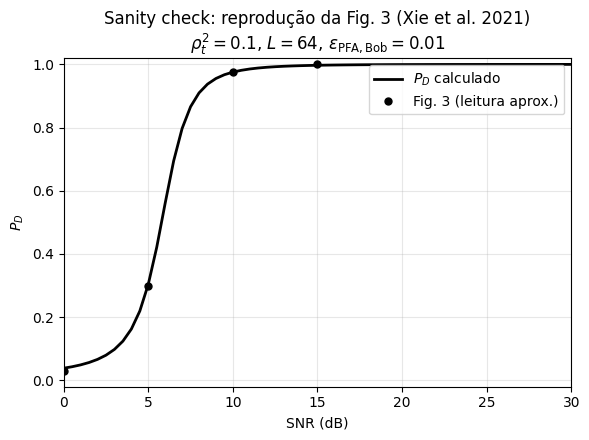

In [8]:
# %%
# ============================================================================
# TESTE DE SANIDADE — reproduzir literalmente a Fig. 3 de Xie et al. (2021)
# ============================================================================
# Parâmetros ORIGINAIS do artigo (NÃO os do nosso dataset): rho_t²=0.1, L=64,
# tag de energia UNITÁRIA (sigma2_tag=1.0, sem a correção 1/3 do mapa caótico).
# Objetivo: validar a implementação de xie_closed_form_rayleigh() contra os
# valores/curva publicados na Fig. 3 do PDF, ANTES de confiar nela com os
# parâmetros do nosso próprio sistema (célula acima).
print("Sanity check — reproduzindo Fig. 3 de Xie et al. (2021):")
print("  rho_t²=0.1, L=64, sigma2_tag=1.0 (tag unitária, como no artigo), alpha=0.01")
_snr_fine = np.arange(0, 30.01, 0.5)
_pd_fine = []
for snr_db in _snr_fine:
    u0, pd = xie_closed_form_rayleigh(L=64, rho_t=np.sqrt(0.1), gBob_db=snr_db,
                                       alpha=0.01, sigma2_tag=1.0)
    _pd_fine.append(pd)
_pd_fine = np.array(_pd_fine)

# Pontos de checagem específicos contra a Fig. 3 (leitura visual do PDF):
for snr_check, pd_fig3_approx in [(0, 0.03), (5, 0.30), (10, 0.975), (15, 1.00)]:
    idx = np.argmin(np.abs(_snr_fine - snr_check))
    print(f"  SNR={snr_check:2d} dB:  PD_calculado={_pd_fine[idx]:.4f}   "
          f"PD_Fig.3 (leitura aprox.)={pd_fig3_approx:.2f}")

fig_sanity, ax_sanity = plt.subplots(figsize=(6, 4.5))

# Curva calculada pela expressão fechada de Xie et al.
ax_sanity.plot(
    _snr_fine,
    _pd_fine,
    'k-',
    linewidth=2,
    label=r'$P_D$ calculado'
)

# Pontos de checagem da Fig. 3 (leitura visual aproximada)
_snr_checks = np.array([0, 5, 10, 15])
_pd_fig3_approx = np.array([0.03, 0.30, 0.975, 1.00])

ax_sanity.plot(
    _snr_checks,
    _pd_fig3_approx,
    'ko',
    markersize=5,
    label='Fig. 3 (leitura aprox.)'
)

ax_sanity.set_xlabel('SNR (dB)')
ax_sanity.set_ylabel(r'$P_D$')

ax_sanity.set_title(
    'Sanity check: reprodução da Fig. 3 (Xie et al. 2021)\n'
    r'$\rho_t^2=0.1$, $L=64$, $\varepsilon_{\mathrm{PFA,Bob}}=0.01$'
)

ax_sanity.grid(alpha=0.3)
ax_sanity.set_xlim(0, 30)
ax_sanity.set_ylim(-0.02, 1.02)

ax_sanity.legend()

plt.tight_layout()

plt.savefig(
    str(visualizations_dir / "NN02c_sanity_check_xie_fig3.png"),
    dpi=120
)

plt.show()

In [5]:
# ==============================================================================
# 5. TABELA DE RESULTADOS E SAVE JSON
# ==============================================================================
# Corrrelador classico (referencia): mesmo procedimento D3F usado nas variantes
# de rede, aplicado diretamente a |tau_eq| (sem rede) -- limiar fixo por bin de
# SNR, calibrado em eta=0.01 (Xie 2021). Recalculado dinamicamente (nao mais
# hardcoded) para refletir sempre o eta atual.
_pd_classical = {}
for snr in SNR_BINS:
    m0 = (snr_val_arr  >= snr-2.5) & (snr_val_arr  < snr+2.5) & (lbl_val_arr  == 0)
    m1 = (snr_test_arr >= snr-2.5) & (snr_test_arr < snr+2.5) & (lbl_test_arr == 1)
    if m0.sum() < 50 or m1.sum() < 10:
        _pd_classical[snr] = 0.0; continue
    mu, sig = tau_val_arr[m0].mean(), tau_val_arr[m0].std()
    if sig < 1e-10:
        _pd_classical[snr] = 0.0; continue
    thr = float(mu + Q_INV_D3F * sig)
    _pd_classical[snr] = float((tau_test_arr[m1] >= thr).mean())
CLASSICAL_PD = {s: round(_pd_classical[s] * 100, 1) for s in SNR_BINS}

# --- NOVO: curva fechada Rayleigh-média (Xie et al. 2021, Eq. 40-41/43-44,
#     generalizada para sigma2_tag != 1 -- ver derivação completa no patch NN_01) ---


with h5py.File(str(dataset_path), 'r') as f:
    _RHO_T_dataset = float(f.attrs['RHO_T'])
    _L_dataset     = int(f.attrs['L_FIXED'])

XIE_CLOSED_FORM_PD = {}
for snr in SNR_BINS:
    _, pd_cf = xie_closed_form_rayleigh(
        L=_L_dataset, rho_t=_RHO_T_dataset, gBob_db=snr,
        alpha=ALPHA_D3F, sigma2_tag=1.0/3.0)
    XIE_CLOSED_FORM_PD[snr] = round(pd_cf * 100, 1)

print(f"\nCorrelador clássico — fórmula fechada Xie (Rayleigh-média, "
      f"rho_t²={_RHO_T_dataset**2:.4f}, L={_L_dataset}, alpha={ALPHA_D3F:.2f}):")
print("  " + "  ".join(f"{s}dB={XIE_CLOSED_FORM_PD[s]:.1f}%" for s in SNR_BINS))
print("\n" + "="*70)
print("ABLATION STUDY --- RESULTADOS DNN (AUC e tempo de treino)")
print("="*70)
print(f"Classico |tau| (D3F, eta={ALPHA_D3F:.2f}): "
      + "  ".join(f"{s}dB={CLASSICAL_PD[s]:.1f}%" for s in SNR_BINS))

for var in ['A', 'A2', 'B', 'B2', 'D', 'E', 'E2', 'F', 'F2']:
    if var not in results_ablation: continue
    r = results_ablation[var]
    pd0 = r['pd_d3f'].get(0, 0)
    print(f"\n  Var {var}: {r['label']}")
    print(f"    val AUC : {r['best_val_auc']:.6f}   Epocas: {r['n_epochs']}"
          f"   Tempo: {r['train_time']:.1f}s")
    print(f"    PD 0 dB : {pd0*100:.1f}%  (D3F eta={ALPHA_D3F:.2f})")

# Salvar JSON
results_json = {
    'metadata': {
        'notebook': 'NN_02c',
        'architecture': 'DNN_256_128_64',
        'alpha_d3f': ALPHA_D3F,
        'q_inv': round(Q_INV_D3F, 6),
        'snr_bins': SNR_BINS,
        'dataset': 'dataset_cnn_yeq_0_30dB.h5',
        'batch_size': BATCH_SIZE,
        'n_train': n_train, 'n_val': n_val, 'n_test': n_test,
        'rho_s': float(RHO_S), 'rho_t': float(RHO_T), 'l_fixed': L_FIXED,
    },
    'classical_correlator': {str(s): CLASSICAL_PD[s]/100 for s in SNR_BINS},
    'variants': {
        var: {
            'label': r['label'],
            'best_val_auc': r['best_val_auc'],
            'n_epochs': r['n_epochs'],
            'train_time_s': round(r['train_time'], 1),
            'pd_d3f': {str(s): r['pd_d3f'][s] for s in SNR_BINS},
        }
        for var, r in results_ablation.items()
    }
}

results_path = models_dir / 'nn02c_ablation_dnn_results.json'
with open(str(results_path), 'w') as f:
    json.dump(results_json, f, indent=2)

print(f"\nResultados salvos -> {results_path}")

NameError: name 'SNR_BINS' is not defined

In [6]:
print(sorted(results_ablation.keys()))

NameError: name 'results_ablation' is not defined

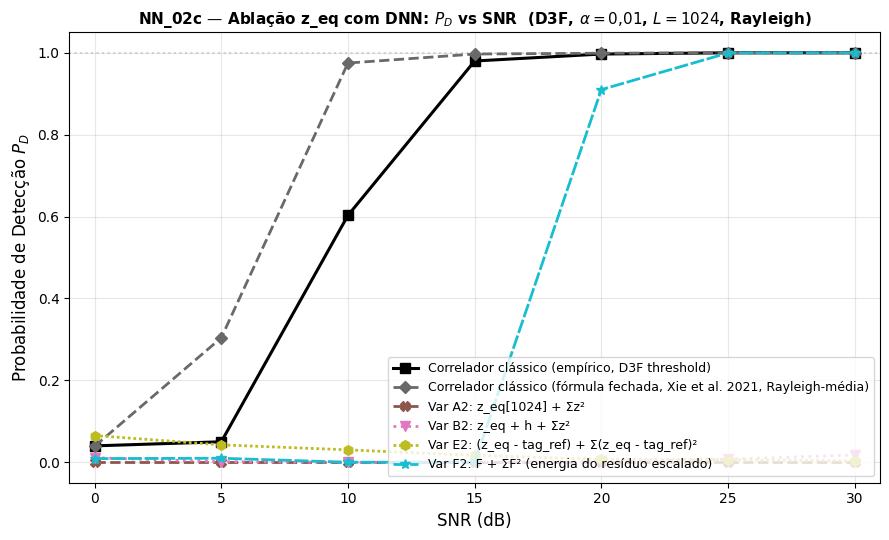

Figura salva → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/Figures2/NN_02c_D3F_PD_vs_SNR_DNN.png

Variante  Input                             0dB      5dB     10dB     15dB     20dB     25dB     30dB
------------------------------------------------------------------------------------------
Clás   Correlador analítico              4.0      5.0     60.3     98.0     99.7    100.0    100.0
A2     z_eq[1024] + Σz²                  0.0      0.0      0.0      0.0      0.0      0.0      0.0
B2     z_eq + h + Σz²                    1.1      0.1      0.0      0.0      0.2      0.8      1.8
E2     (z_eq - tag_ref) + Σ(z_eq - tag_ref)²      6.5      4.2      3.0      1.7      0.7      0.6      0.3
F2     F + ΣF² (energia do resíduo escalado)      0.9      1.0      0.0      0.0     91.0    100.0    100.0
------------------------------------------------------------------------------------------


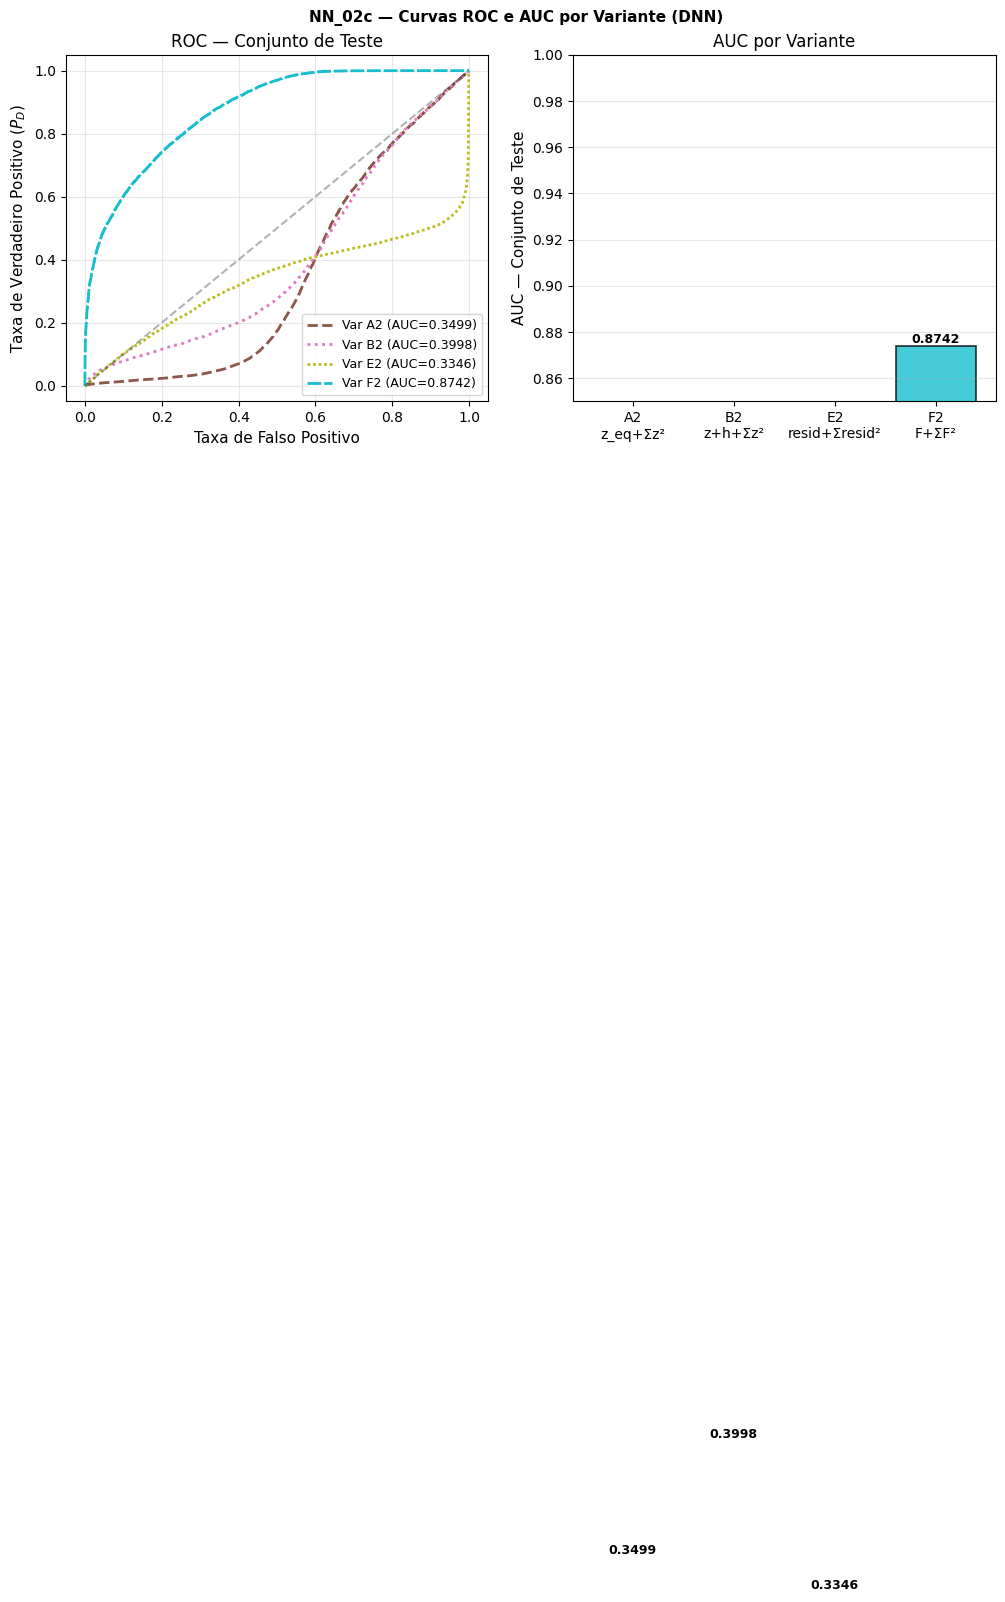

Figura salva → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/Figures2/NN_02c_ROC_AUC_DNN.png


In [11]:
# ==============================================================================
# 6. VISUALIZAÇÕES: D3F PD vs SNR + ROC + AUC
# ==============================================================================

from sklearn.metrics import roc_auc_score, roc_curve

snr_arr    = np.array(SNR_BINS)
COLORS     = {'A': '#d62728', 'A2': '#8c564b', 'B': '#ff7f0e', 'B2': '#e377c2', 'D': '#2ca02c', 'E': '#9467bd', 'E2': '#bcbd22', 'F': '#1f77b4', 'F2': '#17becf'}
MARKERS    = {'A': 'o', 'A2': 'X', 'B': '^', 'B2': 'v', 'F': 's', 'F2': '*', 'D': 'D', 'E': 'P', 'E2': 'h'}
LINESTYLES = {'A': '-', 'A2': '--', 'B': '--', 'B2': ':', 'F': '-.', 'F2': (0, (5, 1)), 'D': ':', 'E': (0, (3, 1, 1, 1)), 'E2': (0, (1, 1))}
VARIANTS_PLOT = ['A', 'A2', 'B', 'B2', 'D', 'E', 'E2', 'F', 'F2']

# Gráfico 1: Probabilidade de detecção versus SNR sob framework D3F
fig1, ax1 = plt.subplots(figsize=(9, 5.5))

# Linha de referência: correlador clássico com limiar analítico
ax1.plot(snr_arr, [CLASSICAL_PD[s]/100 for s in SNR_BINS],
          'k-s', linewidth=2.2, markersize=7,
          label='Correlador clássico (empírico, D3F threshold)')
ax1.plot(snr_arr, [XIE_CLOSED_FORM_PD[s]/100 for s in SNR_BINS],
          color='dimgray', linestyle='--', marker='D', linewidth=2.0, markersize=6,
          label='Correlador clássico (fórmula fechada, Xie et al. 2021, Rayleigh-média)')

# Traços para cada variante
for var in VARIANTS_PLOT:
    if var not in results_ablation: continue
    r  = results_ablation[var]
    pd = [r['pd_d3f'][s] for s in SNR_BINS]
    ax1.plot(snr_arr, pd,
             color=COLORS[var], ls=LINESTYLES[var], lw=2,
             marker=MARKERS[var], ms=7,
             label=f"Var {var}: {r['label']}")

ax1.set_xlabel('SNR (dB)', fontsize=12)
ax1.set_ylabel('Probabilidade de Detecção $P_D$', fontsize=12)
ax1.set_title('NN_02c — Ablação z_eq com DNN: $P_D$ vs SNR  (D3F, $\\alpha=0{,}01$, $L=1024$, Rayleigh)',
              fontsize=11, fontweight='bold')
ax1.set_xlim(-1, 31); ax1.set_ylim(-0.05, 1.05)
ax1.set_xticks(SNR_BINS)
ax1.axhline(1.0, color='gray', ls=':', alpha=0.3)
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(alpha=0.3)
plt.tight_layout()
vis1 = visualizations_dir / 'NN_02c_D3F_PD_vs_SNR_DNN.png'
plt.savefig(str(vis1), dpi=150)
plt.show()
print(f"Figura salva → {vis1}")

# Tabela resumida em formato texto
print(f"\n{'Variante':<5}  {'Input':<28}  " +
      "  ".join(f"{s:>5}dB" for s in SNR_BINS))
print("-" * 90)
cl_vals = "  ".join(f"{CLASSICAL_PD[s]:>7.1f}" for s in SNR_BINS)
print(f"{'Clás':<5}  {'Correlador analítico':<28}  {cl_vals}")
for var in VARIANTS_PLOT:
    if var not in results_ablation: continue
    r = results_ablation[var]
    vals = "  ".join(f"{r['pd_d3f'][s]*100:>7.1f}" for s in SNR_BINS)
    print(f"{var:<5}  {r['label']:<28}  {vals}")
print("-" * 90)

# Gráfico 2: Curvas ROC e AUC por variante
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4.5))
fig3.suptitle('NN_02c — Curvas ROC e AUC por Variante (DNN)', fontsize=11, fontweight='bold')

ax_roc = axes3[0]
for var in VARIANTS_PLOT:
    if var not in results_ablation: continue
    r   = results_ablation[var]
    auc = roc_auc_score(lbl_test_arr, r['sc_test'])
    fpr, tpr, _ = roc_curve(lbl_test_arr, r['sc_test'])
    ax_roc.plot(fpr, tpr, color=COLORS[var], ls=LINESTYLES[var], lw=2,
                label=f"Var {var} (AUC={auc:.4f})")
    results_ablation[var]['auc_test'] = round(auc, 6)

ax_roc.plot([0,1],[0,1],'k--', alpha=0.3)
ax_roc.set_xlabel('Taxa de Falso Positivo', fontsize=11);
ax_roc.set_ylabel('Taxa de Verdadeiro Positivo ($P_D$)', fontsize=11)
ax_roc.set_title('ROC — Conjunto de Teste')
ax_roc.legend(fontsize=9)
ax_roc.grid(alpha=0.3)

# Gráfico de barras: AUC por variante
ax_auc = axes3[1]
aucs  = [results_ablation[v]['auc_test'] for v in VARIANTS_PLOT if v in results_ablation]
vlabs_map = {'A': 'A\nz_eq', 'A2': 'A2\nz_eq+Σz²', 'B': 'B\nz+h', 'B2': 'B2\nz+h+Σz²', 'D': 'D\nz+τ', 'E': 'E\nz-tag_ref', 'E2': 'E2\nresid+Σresid²', 'F': 'F\nresíduo\npré-eq', 'F2': 'F2\nF+ΣF²'}
vlabs = [vlabs_map[v] for v in VARIANTS_PLOT if v in results_ablation]
bars  = ax_auc.bar(vlabs, aucs,
                   color=[COLORS[v] for v in VARIANTS_PLOT if v in results_ablation],
                   alpha=0.8, edgecolor='black', lw=1.2)
for bar, auc in zip(bars, aucs):
    ax_auc.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{auc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_auc.set_ylabel('AUC — Conjunto de Teste', fontsize=11)
ax_auc.set_title('AUC por Variante')
ax_auc.set_ylim([0.85, 1.0])
ax_auc.grid(alpha=0.3, axis='y')

plt.tight_layout()
vis3 = visualizations_dir / 'NN_02c_ROC_AUC_DNN.png'
plt.savefig(str(vis3), dpi=150)
plt.show()
print(f"Figura salva → {vis3}")

In [12]:
# 1. Confirmar se 'snr' armazenado é nominal (pré-fading) ou instantâneo (pós-fading)
print(snr_val_arr[:20])  # deveria ser um valor "de projeto", não |h|²·snr_nom

# 2. Checar a dispersão REAL de snr dentro do bin "0dB"
m0_check = (snr_val_arr >= -2.5) & (snr_val_arr < 2.5) & (lbl_val_arr == 0)
print("min/max/std do snr dentro do bin 0dB:", 
      snr_val_arr[m0_check].min(), snr_val_arr[m0_check].max(), snr_val_arr[m0_check].std())

# 3. Tamanho da amostra por bin (descartar problema de amostra pequena)
print("N amostras H0 no bin 0dB (val):", m0_check.sum())

[27.149487    8.381972   23.977072    0.28683883  0.36036378 10.710591
  8.966919    9.373699    4.6105213  29.832027    7.792148   29.284103
 10.059593   28.838606   19.230928   28.364819    1.4286201   1.3074589
  0.86983496 23.833454  ]
min/max/std do snr dentro do bin 0dB: 0.00045465596 2.4985924 0.7288842
N amostras H0 no bin 0dB (val): 1799


In [13]:
# Comparar limiar/estatísticas empíricas vs. teóricas, no MESMO bin (0dB)
m0 = (snr_val_arr >= -2.5) & (snr_val_arr < 2.5) & (lbl_val_arr == 0)
mu_emp, sig_emp = tau_val_arr[m0].mean(), tau_val_arr[m0].std()
thr_emp = mu_emp + Q_INV_D3F * sig_emp

# Teórico, no MESMO gamma médio real do bin (não snr=0 exato)
gamma_medio_bin = 10**(snr_val_arr[m0].mean()/10)
L_eff = 1024 * (1/3)
sigma_teo = np.sqrt(L_eff / (2 * RHO_T**2 * gamma_medio_bin))  # sigma sob H0, modelo Xie
u0_teo, pd_teo = xie_closed_form_rayleigh(1024, RHO_T, snr_val_arr[m0].mean(), 0.01)

print(f"mu_empirico={mu_emp:.4f}  (teórico: 0.0)")
print(f"sigma_empirico={sig_emp:.4f}  sigma_teorico={sigma_teo:.4f}  razão={sig_emp/sigma_teo:.4f}")
print(f"thr_empirico={thr_emp:.4f}  thr_teorico(u0)={u0_teo:.4f}")

mu_empirico=8.7650  (teórico: 0.0)
sigma_empirico=14.1457  sigma_teorico=20.6884  razão=0.6838
thr_empirico=41.6729  thr_teorico(u0)=144.0853


In [14]:
# ============================================================================= =
# 7. FOCO NAS VARIANTES COM ENERGIA
# ============================================================================= =
if 'E' in results_ablation:
    ranking_auc = sorted(
        ((var, results_ablation[var].get('auc_test', results_ablation[var]['best_val_auc'])) for var in results_ablation),
        key=lambda item: item[1],
        reverse=True
    )
    ranking_pd0 = sorted(
        ((var, results_ablation[var]['pd_d3f'].get(0, 0.0)) for var in results_ablation),
        key=lambda item: item[1],
        reverse=True
    )
    e_auc = results_ablation['E'].get('auc_test', results_ablation['E']['best_val_auc'])
    e_pd0 = results_ablation['E']['pd_d3f'].get(0, 0.0) * 100
    print('Resumo Variante E (DNN):')
    print(f"  AUC      : {e_auc:.6f}")
    print(f"  PD @ 0dB : {e_pd0:.1f}%")
    print(f"  Ranking por AUC : {ranking_auc}")
    print(f"  Ranking por PD@0dB : {ranking_pd0}")
else:
    print('Treine ou recupere a Variante E para gerar este resumo.')

Treine ou recupere a Variante E para gerar este resumo.
